# 07 · Glides: descending spectral ridges

After the acid, a band in the **excess spectrogram** (each frame divided by a quiet baseline spectrum) may
descend smoothly in frequency (Sep 2026: 6.5 → 0.9 kHz in 328 s on one hydrophone, never on the air mic). This
notebook tracks it per channel, tests whether it is real (contrast), checks harmonics, and follows it across takes.

Read `docs/STUDENT_GUIDE.md` §13. The mechanism is not established, and a Minnaert radius read off the ridge
is shown only with its Bond number, as a feasibility check.

In [1]:
# ==== YOUR SETTINGS ====
CONFIG = "../config/demo.yaml"
TAKE = "DEMO_002"
BASE_TAKE = "DEMO_002"        # take that holds the quiet baseline (same sensors, same geometry)
BASELINE = (5.0, 34.0)        # [s] baseline window inside BASE_TAKE
T0 = 46.0                     # [s] start tracking here (after the onset)
SEED = (4000.0, 12000.0)      # [Hz] where to pick up the ridge at T0
FMAX = 20000
LATER_TAKES = ["DEMO_003", "DEMO_004"]   # follow the ridge into later takes (baseline from BASE_TAKE)

In [2]:
# ---- standard setup (same in every notebook) ----
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import zoom_acoustics as za
from zoom_acoustics import plots as zp, dsp

cfg = za.load_config(CONFIG)
print("config   :", cfg.config_file)
print("data_dir :", cfg.data_dir)
print("cache_dir:", cfg.cache_dir)
print("figures  :", cfg.figures_dir)

config   : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/config/demo.yaml
data_dir : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/audio
cache_dir: /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/cache
figures  : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures


In [3]:
from zoom_acoustics import glide as G
f = za.load_features(cfg, TAKE)
fb = za.load_features(cfg, BASE_TAKE)
tracks, rows = {}, []
for c in f.channels:
    tr = G.track_ridge(f, c, BASELINE, T0, seed=SEED, base_feat=fb)
    s = G.summarize(tr)
    if s:
        tracks[c] = tr
        rows.append(dict(channel=c, label=f.label(c), **s))
summary = pd.DataFrame(rows)
summary[["channel", "label", "f_start_hz", "f_end_hz", "octaves", "octaves_per_min",
         "median_contrast_db", "significant", "t_lock_s", "frac_locked",
         "minnaert_R_end_mm", "bond_end", "free_bubble_feasible_at_end"]].round(3)

,channel,label,f_start_hz,f_end_hz,octaves,octaves_per_min,median_contrast_db,significant,t_lock_s,frac_locked,minnaert_R_end_mm,bond_end,free_bubble_feasible_at_end
0,1,Ch1 Hydrophone A,5898.572,4372.236,-0.432,-0.199,5.059,False,46.625,0.372,0.726,0.071,True
1,2,Ch2 Hydrophone B,5898.572,4372.261,-0.432,-0.199,14.721,True,46.625,1.000,0.726,0.071,True
2,3,Ch3 Contact sensor,6374.290,4372.261,-0.544,-0.268,18.692,True,54.375,0.930,0.726,0.071,True
3,4,Ch4 Air mic,4961.445,3847.082,-0.367,-0.169,2.861,False,NaN,0.000,0.825,0.092,True


**Read `significant` first.** A tracker always returns a path, even through pure noise, and a noise path drifts.
Only tracks with median contrast well above ~3 dB are ridges. The air mic is the control: if it "glides" too with
high contrast, the effect is not liquid-borne. `t_lock_s` later than `T0` means the seed started on something else.

[PosixPath('/media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/DEMO_002_glide.png')]

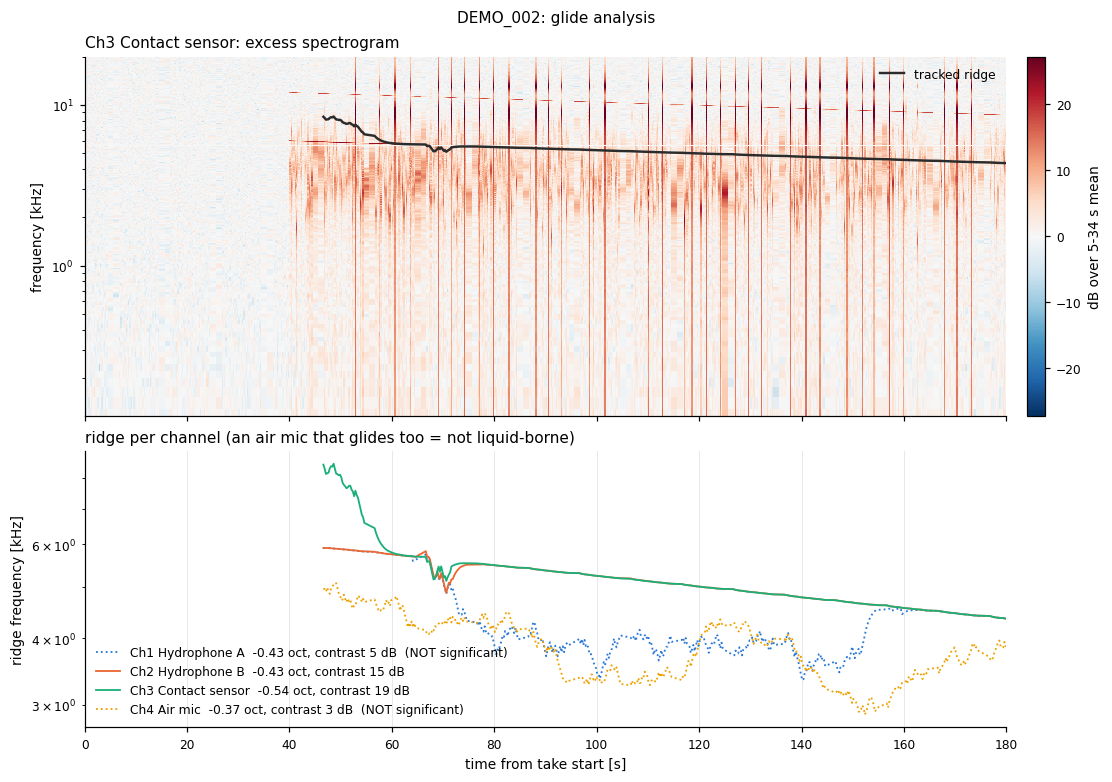

In [4]:
show = int(summary.sort_values("median_contrast_db").channel.iloc[-1]) if len(summary) else f.channels[0]
fig = zp.plot_glide(f, tracks, BASELINE, show_ch=show, fmax=FMAX, base_feat=fb)
zp.save(fig, cfg, f"{TAKE}_glide")

## Harmonics along the ridge

Is there a line at m × f(t)? Non-integer multiples (1.5×, 2.5×) are the noise controls. A strong 0.5× means the
tracked ridge is itself a **harmonic**: re-seed lower.

In [5]:
G.harmonic_ladder(f, show, BASELINE, tracks[show], base_feat=fb).round(2)

,multiple,control,n_frames,median_contrast_dB,frac_above_3dB
0,0.5,False,443,1.70,0.24
1,1.0,False,443,18.92,0.92
2,1.5,True,443,2.38,0.29
3,2.0,False,443,17.59,0.89
4,2.5,True,428,2.70,0.35
5,3.0,False,411,2.82,0.41
6,4.0,False,197,2.77,0.37
7,5.0,False,0,NaN,NaN


## Following the ridge into later takes

Each later take is tracked with the baseline of `BASE_TAKE`, seeded near where the ridge was last seen. Only
valid if nothing was moved or re-gained between takes.

In [6]:
all_rows = [dict(take=TAKE, **r) for r in rows]
last = {r["channel"]: r["f_end_hz"] for r in rows}
for name in LATER_TAKES:
    fl = za.load_features(cfg, name)
    for c in fl.channels:
        if c not in last:
            continue
        tr = G.track_ridge(fl, c, BASELINE, 1.0, seed=(0.7 * last[c], 1.3 * last[c]), base_feat=fb)
        s = G.summarize(tr)
        if s:
            all_rows.append(dict(take=name, channel=c, label=fl.label(c), **s))
            if s["significant"]:
                last[c] = s["f_end_hz"]
tab = pd.DataFrame(all_rows)
tab[["take", "channel", "f_start_hz", "f_end_hz", "octaves", "median_contrast_db", "significant"]].round(2)

,take,channel,f_start_hz,f_end_hz,octaves,median_contrast_db,significant
0,DEMO_002,1,5898.57,4372.24,-0.43,5.06,False
1,DEMO_002,2,5898.57,4372.26,-0.43,14.72,True
2,DEMO_002,3,6374.29,4372.26,-0.54,18.69,True
3,DEMO_002,4,4961.44,3847.08,-0.37,2.86,False
4,DEMO_003,1,3760.60,2692.09,-0.48,14.67,True
5,DEMO_003,2,3760.60,2692.13,-0.48,17.30,True
6,DEMO_004,1,2156.25,1656.55,-0.38,25.48,True


In [7]:
tab.to_csv(cfg.figures_path / "glide_summary.csv", index=False)
print("wrote", cfg.figures_path / "glide_summary.csv")

wrote /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/glide_summary.csv


## Interpretation: what would each mechanism need?

`glide.interpret` turns the ridge f(t) into the parameter each candidate mechanism requires
(`docs/GLIDE_INTERPRETATION.md` has the physics):

* **A, one growing bubble:** Minnaert radius R(t) and growth rate. Bond number ≥ 1 (R above the 2.73 mm
  capillary length) means impossible as a free sphere. A bubble on a wall rings 0.816× lower, so it can be
  smaller.
* **B, a bubbly layer:** Wood's-law void fraction for assumed layer thicknesses. Gaps mean no void fraction
  ≤ 2 % works.

This does not identify the mechanism. It shows which readings are physically possible. Discriminating
tests (depth dependence, sensor dependence, odd vs integer harmonics, a camera) are in the doc.

,hypothesis,requires,physical,note
0,A: one free bubble growing,"R 0.39-0.72 mm, median dR/dt 1.7 um/s",True,Bond max 0.07 (>= 1 impossible as a free sphere)
1,A': bubble touching a wall,R 0.32-0.59 mm,True,"a wall lowers f (x0.816 touching), so the SAME..."
2,"B: bubbly layer, thickness 5mm",void fraction 5.0e-03-1.7e-02,True,beta must RISE as f falls; check against gas p...
3,"B: bubbly layer, thickness 10mm",void fraction 1.2e-03-4.3e-03,True,beta must RISE as f falls; check against gas p...
4,"B: bubbly layer, thickness 20mm",void fraction 2.5e-04-1.0e-03,True,beta must RISE as f falls; check against gas p...
5,"B: bubbly layer, thickness 40mm",void fraction 1.8e-05-2.1e-04,True,beta must RISE as f falls; check against gas p...


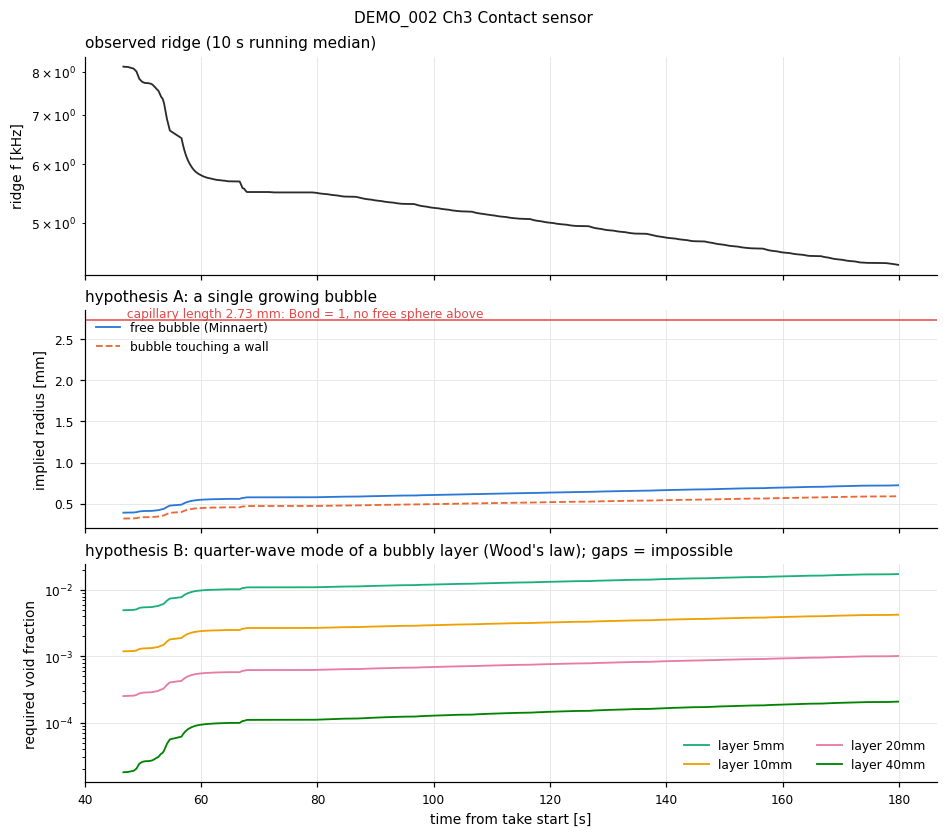

In [8]:
best = int(summary.sort_values("median_contrast_db").channel.iloc[-1])
it = G.interpret(tracks[best], depths_m=(0.005, 0.01, 0.02, 0.04))
fig = zp.plot_glide_interpretation(it, f"{TAKE} {f.label(best)}")
zp.save(fig, cfg, f"{TAKE}_glide_interpretation")
G.interpretation_summary(it)